# Environmental Sensor Data Monitoring

# Problem Statement :  Water quality across India shows wide variation due to pollution, industrial discharge, and poor environmental management. The available sensor data is often noisy, incomplete, and difficult to interpret directly. There is a need to clean this data, detect anomalies, compute a reliable Water Quality Index (WQI), and visualize trends so that authorities can easily identify polluted locations, compare water bodies, and make informed environmental decisions.

# Name : Prakhar Khandelwal
# Data Analyst Intern

# IMPORTING THE LIBRARIES

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

# LOAD THE DATASET

In [71]:
df = pd.read_csv(r"C:\Users\Prakhar Khandelwal\Desktop\water_quality_data.csv")
df.head()

,stn_code,monitoring_location,year,type_water_body,state_name,temperature_min,temperature_max,dissolved_min,dissolved_max,ph_min,ph_max,conductivity_min,conductivity_max,bod_mg_min,bod_mgl_max,nitraten_mgl_min,nitraten_mgl_max,fecal_coliform_mpn100ml_min,fecal_coliform_mpn100ml_max
0,3376,"BIT MESRA, RANCHI",2017,Lake,JHARKHAND,8.44,30.86,4.94,8.70,6.81,7.84,148.71,175.81,1.33,6.98,3.35,12.85,21,214
1,6121,KANKE DAM,2021,River,JHARKHAND,19.48,24.93,4.25,6.33,6.48,7.66,73.35,155.76,2.90,5.87,2.33,11.67,3,405
2,2524,MASANJORE DAM,2015,Lake,HIMACHAL PRADESH,19.54,27.90,2.90,8.22,6.69,8.08,94.20,183.18,2.25,5.59,1.27,8.37,49,117
3,4441,BOKARO,2008,Pond,UTTARAKHAND,17.96,31.08,5.45,8.56,6.50,7.37,53.76,246.48,1.21,5.09,0.11,16.49,18,186
4,3669,TENUGH DAM,2010,Lake,HIMACHAL PRADESH,11.13,29.97,2.16,6.31,6.76,8.61,146.01,206.68,2.10,5.33,2.44,19.36,36,251


# Data Cleaning

In [92]:
df_clean.info

<bound method DataFrame.info of      stn_code monitoring_location  year type_water_body        state_name  \
0        3376   BIT MESRA, RANCHI  2017            Lake         JHARKHAND   
1        6121           KANKE DAM  2021           River         JHARKHAND   
2        2524       MASANJORE DAM  2015            Lake  HIMACHAL PRADESH   
3        4441              BOKARO  2008            Pond       UTTARAKHAND   
4        3669          TENUGH DAM  2010            Lake  HIMACHAL PRADESH   
..        ...                 ...   ...             ...               ...   
315      4066       VISAKHAPATNAM  2021            Lake  HIMACHAL PRADESH   
316      3316            KAKINADA  2017            Lake  HIMACHAL PRADESH   
317      7256       TIUNIKAKINADA  2022       Reservoir  HIMACHAL PRADESH   
318      5850            KAKINADA  2009            Pond  HIMACHAL PRADESH   
319      4032        NARSAPUR (M)  2004           River  HIMACHAL PRADESH   

     avg_temperature  avg_dissolved  avg_ph

In [93]:
df_clean.describe

<bound method NDFrame.describe of      stn_code monitoring_location  year type_water_body        state_name  \
0        3376   BIT MESRA, RANCHI  2017            Lake         JHARKHAND   
1        6121           KANKE DAM  2021           River         JHARKHAND   
2        2524       MASANJORE DAM  2015            Lake  HIMACHAL PRADESH   
3        4441              BOKARO  2008            Pond       UTTARAKHAND   
4        3669          TENUGH DAM  2010            Lake  HIMACHAL PRADESH   
..        ...                 ...   ...             ...               ...   
315      4066       VISAKHAPATNAM  2021            Lake  HIMACHAL PRADESH   
316      3316            KAKINADA  2017            Lake  HIMACHAL PRADESH   
317      7256       TIUNIKAKINADA  2022       Reservoir  HIMACHAL PRADESH   
318      5850            KAKINADA  2009            Pond  HIMACHAL PRADESH   
319      4032        NARSAPUR (M)  2004           River  HIMACHAL PRADESH   

     avg_temperature  avg_dissolved  avg_

In [94]:
df_clean.isnull().sum()

stn_code               0
monitoring_location    0
year                   0
type_water_body        0
state_name             0
avg_temperature        0
avg_dissolved          0
avg_ph                 0
avg_conductivity       0
avg_bod                0
avg_nitraten           0
avg_fecal_coliform     0
anomaly_zscore         0
is_anomaly_z           0
wqi                    0
wqi_category           0
is_anomaly_iqr         0
dtype: int64

In [72]:
df_clean = df.copy()

In [73]:
df_clean.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
    .str.replace("-", "")
)

In [76]:
df_clean.head()

,stn_code,monitoring_location,year,type_water_body,state_name,temperature_min,temperature_max,dissolved_min,dissolved_max,ph_min,...,nitraten_mgl_max,fecal_coliform_mpn100ml_min,fecal_coliform_mpn100ml_max,avg_temperature,avg_dissolved,avg_ph,avg_conductivity,avg_bod,avg_nitraten,avg_fecal_coliform
0,3376,"BIT MESRA, RANCHI",2017,Lake,JHARKHAND,8.44,30.86,4.94,8.70,6.81,...,12.85,21,214,19.650,6.820,7.325,162.260,4.155,8.10,117.5
1,6121,KANKE DAM,2021,River,JHARKHAND,19.48,24.93,4.25,6.33,6.48,...,11.67,3,405,22.205,5.290,7.070,114.555,4.385,7.00,204.0
2,2524,MASANJORE DAM,2015,Lake,HIMACHAL PRADESH,19.54,27.90,2.90,8.22,6.69,...,8.37,49,117,23.720,5.560,7.385,138.690,3.920,4.82,83.0
3,4441,BOKARO,2008,Pond,UTTARAKHAND,17.96,31.08,5.45,8.56,6.50,...,16.49,18,186,24.520,7.005,6.935,150.120,3.150,8.30,102.0
4,3669,TENUGH DAM,2010,Lake,HIMACHAL PRADESH,11.13,29.97,2.16,6.31,6.76,...,19.36,36,251,20.550,4.235,7.685,176.345,3.715,10.90,143.5


# Data Preprocessing

In [95]:
def combine_avg(df_clean, min_col, max_col, new_col):
    if min_col in df_clean.columns and max_col in df_clean.columns:
        df_clean[new_col] = df_clean[[min_col, max_col]].mean(axis=1)
    return df_clean

In [96]:
df_clean = combine_avg(df, "temperature_min", "temperature_max", "avg_temperature")
df_clean = combine_avg(df, "dissolved_min", "dissolved_max", "avg_dissolved")
df_clean = combine_avg(df, "ph_min", "ph_max", "avg_ph")
df_clean = combine_avg(df, "conductivity_min", "conductivity_max", "avg_conductivity")
df_clean = combine_avg(df, "bod_mg_min", "bod_mgl_max", "avg_bod")
df_clean = combine_avg(df, "nitraten_mgl_min", "nitraten_mgl_max", "avg_nitraten")
df_clean = combine_avg(df, "fecal_coliform_mpn100ml_min", "fecal_coliform_mpn100ml_max", "avg_fecal_coliform")

In [77]:
# Drop original min/max columns
df_clean = df_clean.loc[:, ~df_clean.columns.str.contains("_min|_max")]

In [78]:
# Fill missing numeric values
df_clean.fillna(df_clean.mean(numeric_only=True), inplace=True)

C:\Users\Prakhar Khandelwal\AppData\Local\Temp\ipykernel_4588\3951685252.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.fillna(df_clean.mean(numeric_only=True), inplace=True)


In [87]:
Q1 = df_clean["wqi"].quantile(0.25)
Q3 = df_clean["wqi"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean["is_anomaly_iqr"] = (df_clean["wqi"] < lower) | (df_clean["wqi"] > upper)

C:\Users\Prakhar Khandelwal\AppData\Local\Temp\ipykernel_4588\2476820858.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["is_anomaly_iqr"] = (df_clean["wqi"] < lower) | (df_clean["wqi"] > upper)


In [81]:
# WQI Calculation
# -----------------------------------------------
df_clean["wqi"] = (
    0.3 * df_clean["avg_dissolved"] +
    0.2 * df_clean["avg_ph"] +
    0.2 * (1 / df_clean["avg_bod"]) +
    0.2 * (1 / df_clean["avg_conductivity"]) +
    0.1 * (1 / df_clean["avg_fecal_coliform"])
)

C:\Users\Prakhar Khandelwal\AppData\Local\Temp\ipykernel_4588\884954519.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["wqi"] = (


In [82]:
# Categorization
def categorize_wqi(w):
    if w > 3: return "Excellent"
    elif w > 2.5 and w < 3: return "Moderate"
    else: return "Poor"

df_clean["wqi_category"] = df_clean["wqi"].apply(categorize_wqi)

C:\Users\Prakhar Khandelwal\AppData\Local\Temp\ipykernel_4588\4149490593.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["wqi_category"] = df_clean["wqi"].apply(categorize_wqi)


In [53]:
df_clean.head(30)

,stn_code,monitoring_location,year,type_water_body,state_name,avg_temperature,avg_dissolved,avg_ph,avg_conductivity,avg_bod,avg_nitraten,avg_fecal_coliform,wqi,wqi_category
0,3376,"BIT MESRA, RANCHI",2017,Lake,JHARKHAND,19.65,6.82,7.32,162.26,4.16,8.100,117.5,3.56,Excellent
1,6121,KANKE DAM,2021,River,JHARKHAND,22.20,5.29,7.07,114.56,4.38,7.000,204.0,3.05,Excellent
2,2524,MASANJORE DAM,2015,Lake,HIMACHAL PRADESH,23.72,5.56,7.38,138.69,3.92,4.820,83.0,3.20,Excellent
3,4441,BOKARO,2008,Pond,UTTARAKHAND,24.52,7.01,6.94,150.12,3.15,8.300,102.0,3.55,Excellent
4,3669,TENUGH DAM,2010,Lake,HIMACHAL PRADESH,20.55,4.23,7.68,176.34,3.72,10.900,143.5,2.86,Moderate
5,9134,NEAR TELMUCHO BRIDGE,2020,Pond,HIMACHAL PRADESH,19.31,4.60,6.78,223.62,2.23,2.890,179.0,2.83,Moderate
6,3950,ZARANGDIH BRIDGE,2006,River,HIMACHAL PRADESH,21.34,5.35,7.70,138.37,3.32,5.535,200.0,3.20,Excellent
7,7089,"BOLBA, JHARKHAND",2013,Lake,HIMACHAL PRADESH,16.01,6.15,7.31,216.12,2.68,9.110,166.0,3.38,Excellent
8,5074,MAITHAN DAM,2008,Reservoir,HIMACHAL PRADESH,17.45,7.42,6.74,178.12,4.57,6.315,204.5,3.62,Excellent
9,4175,BOKARO,2024,River,HIMACHAL PRADESH,17.14,6.51,6.85,149.64,4.61,6.805,114.0,3.37,Excellent


In [83]:
cols_to_round = ['wqi', 'avg_temperature', 'avg_dissolved', 'avg_ph','avg_conductivity','avg_bod']
df_clean[cols_to_round] = df_clean[cols_to_round].round(2)

C:\Users\Prakhar Khandelwal\AppData\Local\Temp\ipykernel_4588\70742736.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[cols_to_round] = df_clean[cols_to_round].round(2)


In [84]:
df_clean.head()

,stn_code,monitoring_location,year,type_water_body,state_name,avg_temperature,avg_dissolved,avg_ph,avg_conductivity,avg_bod,avg_nitraten,avg_fecal_coliform,anomaly_zscore,is_anomaly_z,wqi,wqi_category
0,3376,"BIT MESRA, RANCHI",2017,Lake,JHARKHAND,19.65,6.82,7.32,162.26,4.16,8.10,117.5,0.907994,False,3.56,Excellent
1,6121,KANKE DAM,2021,River,JHARKHAND,22.20,5.29,7.07,114.56,4.38,7.00,204.0,1.947129,False,3.05,Excellent
2,2524,MASANJORE DAM,2015,Lake,HIMACHAL PRADESH,23.72,5.56,7.38,138.69,3.92,4.82,83.0,1.319500,False,3.20,Excellent
3,4441,BOKARO,2008,Pond,UTTARAKHAND,24.52,7.01,6.94,150.12,3.15,8.30,102.0,1.522859,False,3.55,Excellent
4,3669,TENUGH DAM,2010,Lake,HIMACHAL PRADESH,20.55,4.23,7.68,176.34,3.72,10.90,143.5,2.074248,False,2.86,Moderate


# Data Visualization

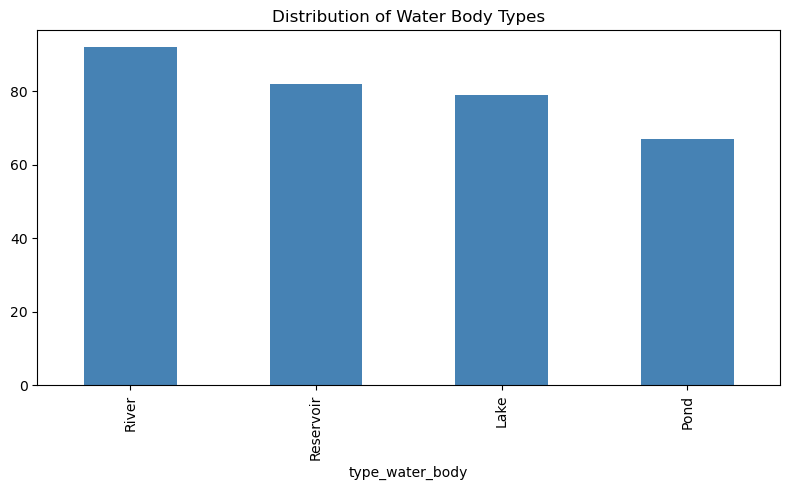

In [30]:
# 1. Distribution of water body types

plt.figure(figsize=(8,5))
df_clean["type_water_body"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Distribution of Water Body Types")
plt.tight_layout()

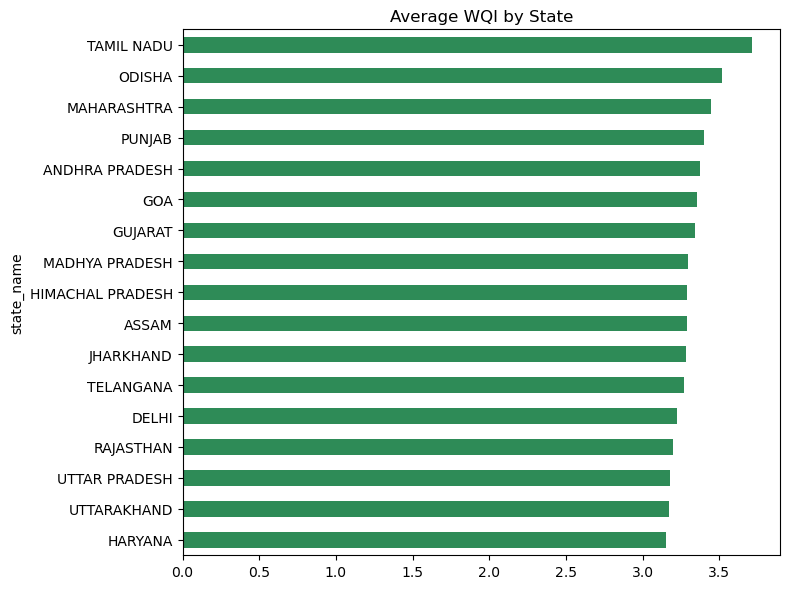

In [32]:
# 2. Average WQI by state
plt.figure(figsize=(8,6))
df_clean.groupby("state_name")["wqi"].mean().sort_values().plot(kind="barh", color="seagreen")
plt.title("Average WQI by State")
plt.tight_layout()

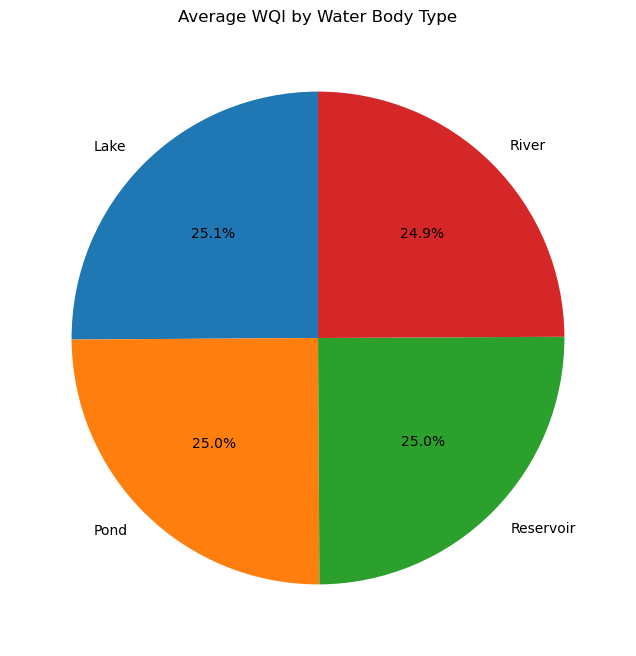

In [37]:
# 3. Average WQI by Water Body Type
plt.figure(figsize=(8, 8))
avg_wqi = df_clean.groupby("type_water_body")["wqi"].mean()
plt.pie(avg_wqi, labels=avg_wqi.index, autopct="%1.1f%%", startangle=90)
plt.title("Average WQI by Water Body Type")
plt.show()

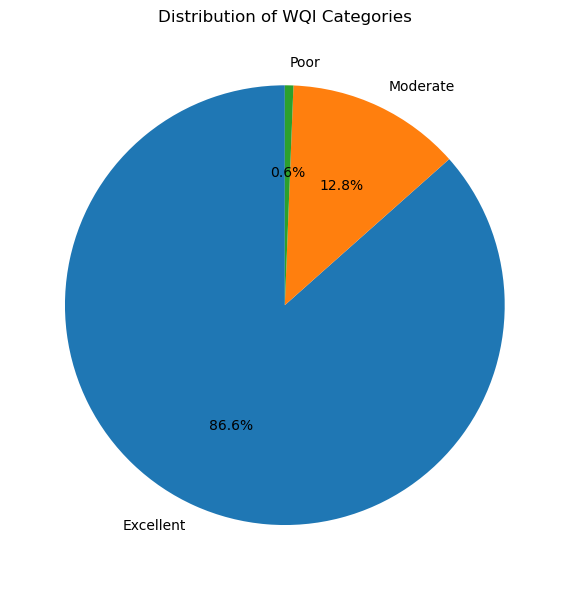

In [54]:
# 4. Distribution of WQI Categories (Pie Chart)
plt.figure(figsize=(8, 6))
df_clean["wqi_category"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90,shadow=False)
plt.title("Distribution of WQI Categories")
plt.ylabel("")   # Removes the y-label for cleaner look
plt.tight_layout()
plt.savefig("wqi_category_distribution_pie.png", dpi=300)
plt.show()

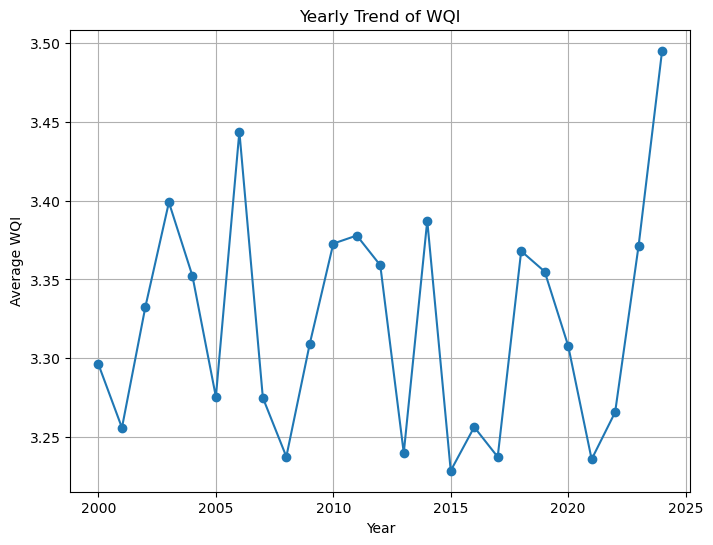

In [56]:
# 5. Yearly Trend of WQI
plt.figure(figsize=(8, 6))
yearly_wqi = df_clean.groupby("year")["wqi"].mean()
plt.plot(yearly_wqi.index, yearly_wqi.values, marker="o")
plt.title("Yearly Trend of WQI")
plt.xlabel("Year")
plt.ylabel("Average WQI")
plt.grid(True)

<Figure size 1200x600 with 0 Axes>

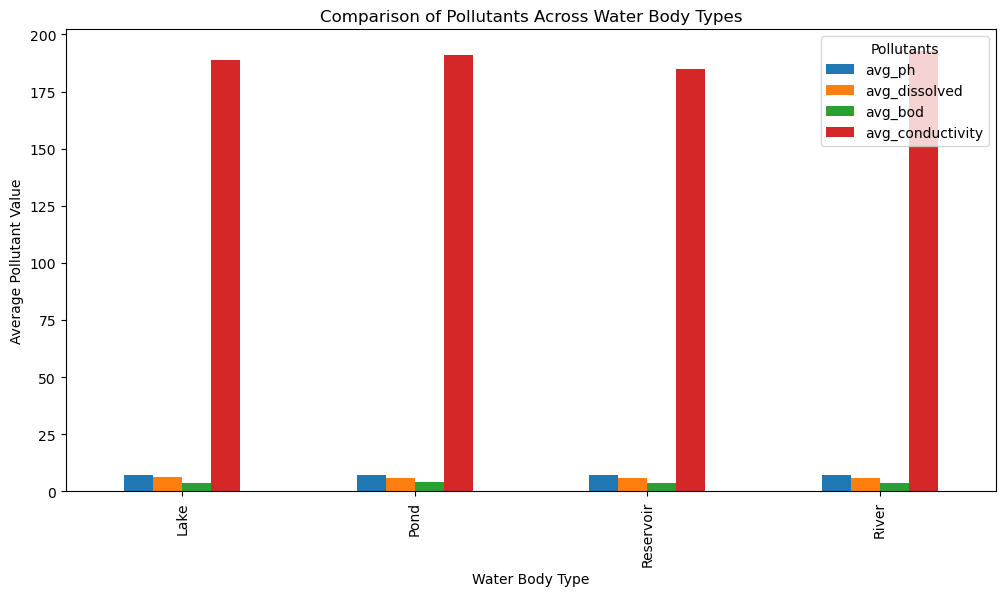

In [58]:
# 6. Pollutants Comparison by Water Body
plt.figure(figsize=(12, 6))
pollutants = ["avg_ph", "avg_dissolved", "avg_bod", "avg_conductivity"]
df_pollutants = df_clean.groupby("type_water_body")[pollutants].mean()
df_pollutants.plot(kind="bar", figsize=(12, 6))
plt.title("Comparison of Pollutants Across Water Body Types")
plt.xlabel("Water Body Type")
plt.ylabel("Average Pollutant Value")
plt.legend(title="Pollutants")
plt.show()

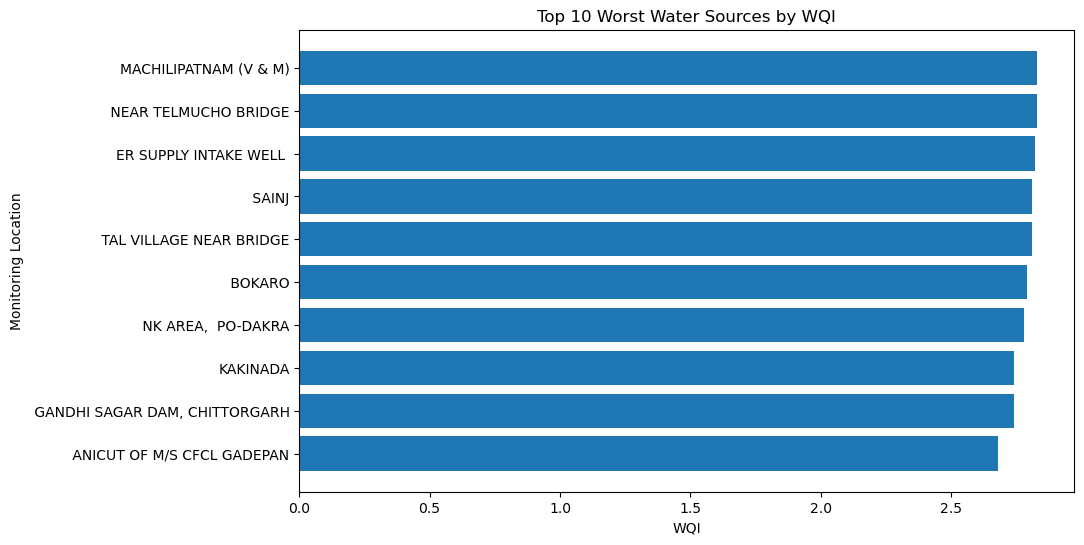

In [63]:
# 7. Top 10 Water Sources by WQI (Worst → Best)
plt.figure(figsize=(10, 6))
top10 = df_clean.sort_values("wqi").head(10)
plt.barh(top10["monitoring_location"], top10["wqi"])
plt.title("Top 10 Worst Water Sources by WQI")
plt.xlabel("WQI")
plt.ylabel("Monitoring Location")
plt.savefig("top10_worst_locations.png", dpi=300)
plt.show()

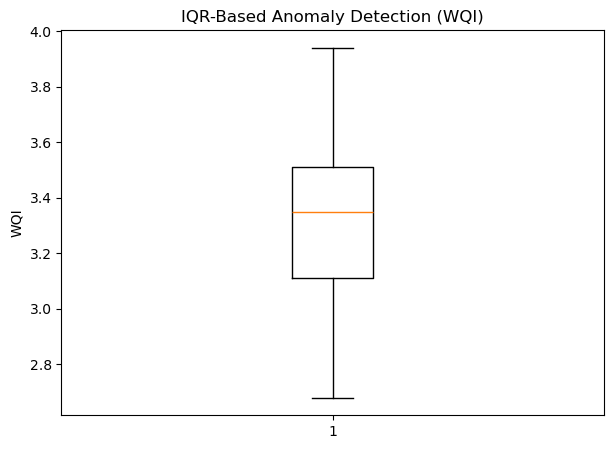

In [88]:
plt.figure(figsize=(7,5))
plt.boxplot(df_clean["wqi"])
plt.title("IQR-Based Anomaly Detection (WQI)")
plt.ylabel("WQI")
plt.show()

In [90]:
df_clean.to_csv("final_dataset.csv", index=False)